# Thesis Figures — Missing Visualizations

Generates 4 new thesis-quality figures + fixed dendrogram, in both French and English.

- **Fig. A:** Heritage divergence — 10 small multiples (Ch.2 S2)
- **Fig. B:** Treaty beeswarm scatter (Ch.2 S1)
- **Fig. C:** Correlation matrix (Ch.2 S2)
- **Fig. D:** Score distribution boxplot (Ch.2 S2)
- **Fig. E:** Fixed dendrogram — horizontal (Ch.2 S2)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'scripts'))
from figure_style import *
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

apply_style()
DATA = load_data()

# Build feature matrix
fm = pd.DataFrame(DATA['feature_matrix'])
fm['heritage'] = fm['PAYS'].map(DATA['colonial_heritage'])
fm['post_conflict'] = fm['PAYS'].map(DATA['post_conflict']).fillna(False)
fm['total_score'] = fm[FEATURES].sum(axis=1)

# Tier 1
tier1 = fm[fm['heritage'].isin(['francophone', 'anglophone'])].copy()

print(f'Loaded: {len(fm)} countries, Tier 1: {len(tier1)}')

Loaded: 54 countries, Tier 1: 42


## Figure A: Heritage Divergence — 10 Small Multiples

Left column: identity dimensions (diverge post-1990). Right column: institutional dimensions (converge).

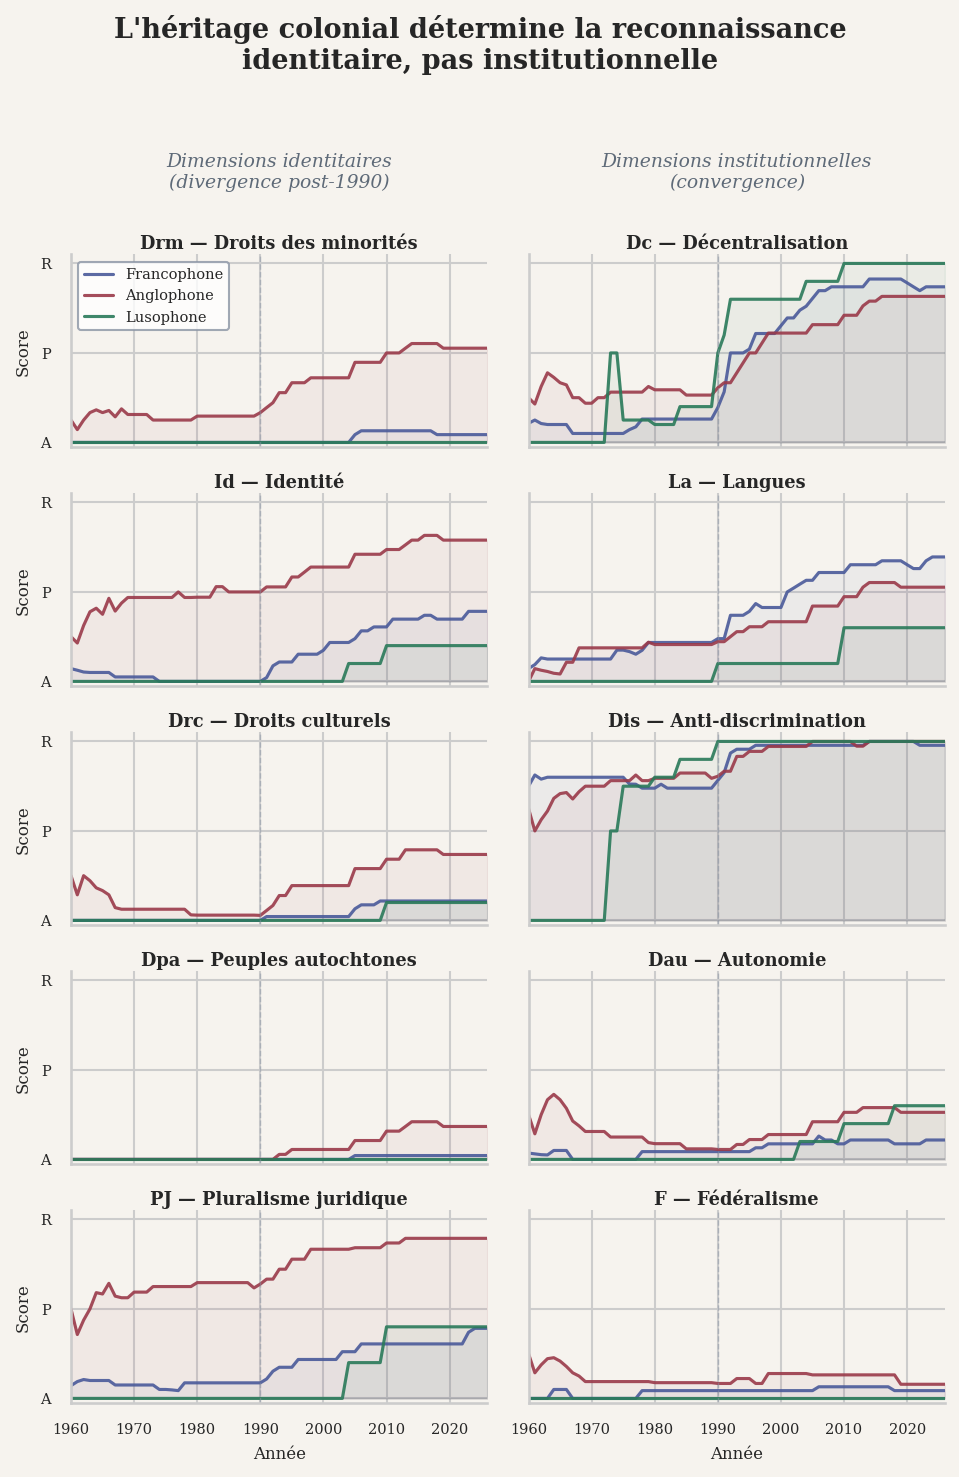

Saved: ch2s2_heritage_divergence (fr + en)


In [2]:
div_data = DATA['heritage_divergence']

# Layout: identity left, institutional right
left_dims = ['Drm', 'Id', 'Drc', 'Dpa', 'PJ']   # identity cluster
right_dims = ['Dc', 'La', 'Dis', 'Dau', 'F']     # institutional/baseline

for lang in ('fr', 'en'):
    fig, axes = plt.subplots(5, 2, figsize=(6.5, 10), sharex=True, sharey=True)
    fig.suptitle(t('heritage_divergence_title', lang), fontsize=13, fontweight='bold',
                 fontfamily='serif', y=0.98)

    for col_idx, (dims, col_label_key) in enumerate([
        (left_dims, 'heritage_divergence_left'),
        (right_dims, 'heritage_divergence_right'),
    ]):
        for row_idx, feat in enumerate(dims):
            ax = axes[row_idx, col_idx]
            dim_data = div_data.get(feat, {})

            for h in ['francophone', 'anglophone', 'lusophone']:
                series = dim_data.get(h, [])
                if series:
                    years = [p[0] for p in series]
                    scores = [p[1] for p in series]
                    ax.plot(years, scores, color=HC[h], linewidth=1.5, alpha=0.9,
                            label=hl(h, lang) if row_idx == 0 and col_idx == 0 else None)
                    ax.fill_between(years, 0, scores, color=HC[h], alpha=0.06)

            # 1990 line
            ax.axvline(1990, color=C_DIM, linestyle='--', linewidth=0.7, alpha=0.5)

            # Panel title
            dim_label = t('dim', lang)[feat]
            ax.set_title(f'{feat} — {dim_label}', fontsize=8.5, fontweight='bold', pad=3)
            ax.set_ylim(-0.05, 2.1)
            ax.set_xlim(1960, 2026)

            if row_idx == 4:
                ax.set_xlabel(t('functional_emergence_xlabel', lang), fontsize=8)
            if col_idx == 0:
                ax.set_ylabel('Score', fontsize=8)

            # Y ticks
            ax.set_yticks([0, 1, 2])
            ax.set_yticklabels([t('absent', lang)[0], t('partial', lang)[0], t('recognized', lang)[0]],
                              fontsize=7)
            ax.tick_params(axis='x', labelsize=7)

        # Column header
        axes[0, col_idx].annotate(t(col_label_key, lang), xy=(0.5, 1.35),
                                  xycoords='axes fraction', ha='center', fontsize=9,
                                  fontstyle='italic', color=C_MUTED)

    # Legend on first panel
    axes[0, 0].legend(fontsize=7, loc='upper left', frameon=True, facecolor='white',
                       edgecolor=C_DIM)

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    save_fig(fig, 'ch2s2_heritage_divergence', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch2s2_heritage_divergence (fr + en)')

## Figure B: Treaty Beeswarm Scatter

Treaty count (x) vs constitutional score (y). Dots by heritage, diamonds for post-conflict.

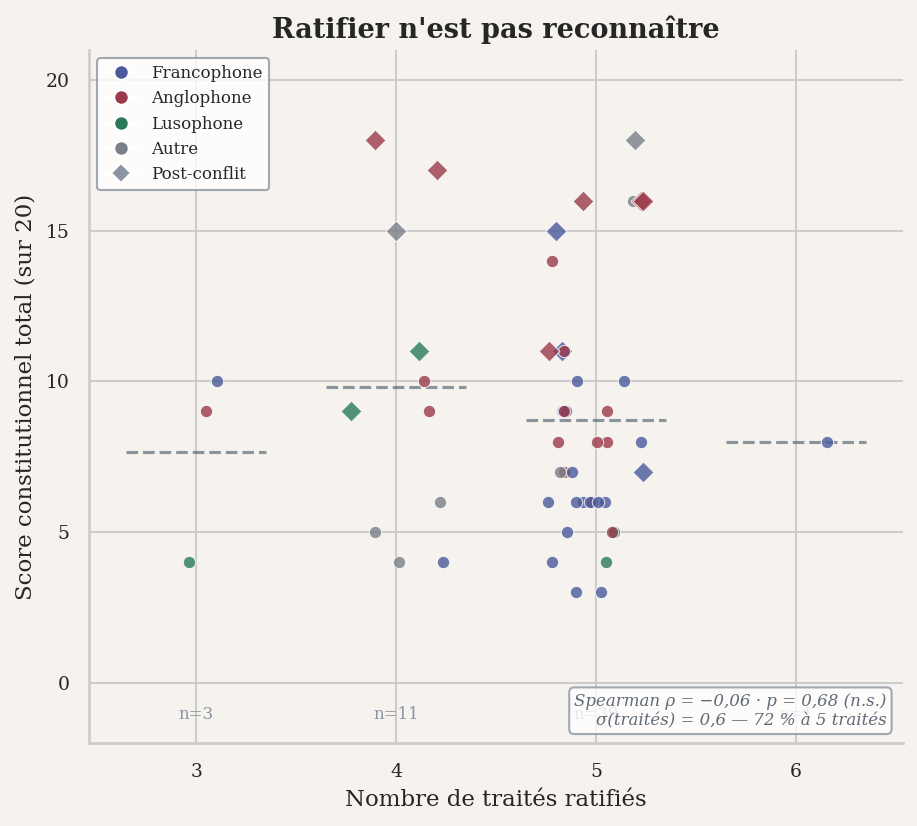

Saved: ch2s1_treaty_beeswarm (fr + en)


In [3]:
# Compute treaty counts
treaties = DATA['treaties']
ratif = DATA['ratif_data']

fm['treaty_count'] = fm['PAYS'].apply(
    lambda c: sum(1 for tr in treaties if ratif.get(c, {}).get(tr) in ('P', 'V'))
)

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(7, 6))

    # Jitter within each treaty count column
    np.random.seed(42)
    for _, row in fm.iterrows():
        x = row['treaty_count'] + np.random.uniform(-0.25, 0.25)
        y = row['total_score']
        color = HC.get(row['heritage'], C_DIM)
        marker = 'D' if row['post_conflict'] else 'o'
        size = 50 if row['post_conflict'] else 35
        ax.scatter(x, y, c=color, marker=marker, s=size, alpha=0.8,
                   edgecolors='white', linewidths=0.5, zorder=3)

    # Per-column means
    for tc in sorted(fm['treaty_count'].unique()):
        subset = fm[fm['treaty_count'] == tc]
        mean_score = subset['total_score'].mean()
        ax.plot([tc - 0.35, tc + 0.35], [mean_score, mean_score],
                color=C_MUTED, linewidth=1.5, linestyle='--', alpha=0.7)
        ax.text(tc, -1.2, f'n={len(subset)}', ha='center', fontsize=8, color=C_DIM)

    # Statistical annotation
    rho, p = spearmanr(fm['treaty_count'], fm['total_score'])
    ax.text(0.98, 0.02, t('treaty_beeswarm_annot', lang),
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
            color=C_MUTED, style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C_DIM, alpha=0.8))

    # Legend
    legend_elements = []
    for h in ['francophone', 'anglophone', 'lusophone', 'other']:
        legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=HC[h],
                                      markersize=7, label=hl(h, lang)))
    legend_elements.append(Line2D([0], [0], marker='D', color='w', markerfacecolor=C_DIM,
                                  markersize=7, label=t('pc_post_conflict', lang)))
    ax.legend(handles=legend_elements, loc='upper left', frameon=True, facecolor='white',
              edgecolor=C_DIM, fontsize=8)

    ax.set_xlabel(t('treaty_beeswarm_xlabel', lang), fontsize=11)
    ax.set_ylabel(t('treaty_beeswarm_ylabel', lang), fontsize=11)
    ax.set_title(t('treaty_beeswarm_title', lang), fontsize=13, fontweight='bold', fontfamily='serif')
    ax.set_ylim(-2, 21)
    ax.set_xticks(sorted(fm['treaty_count'].unique()))

    save_fig(fig, 'ch2s1_treaty_beeswarm', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch2s1_treaty_beeswarm (fr + en)')

## Figure C: Correlation Matrix (Tier 1)

Pearson correlations between 10 dimensions, reordered to show the identity cluster in the top-left.

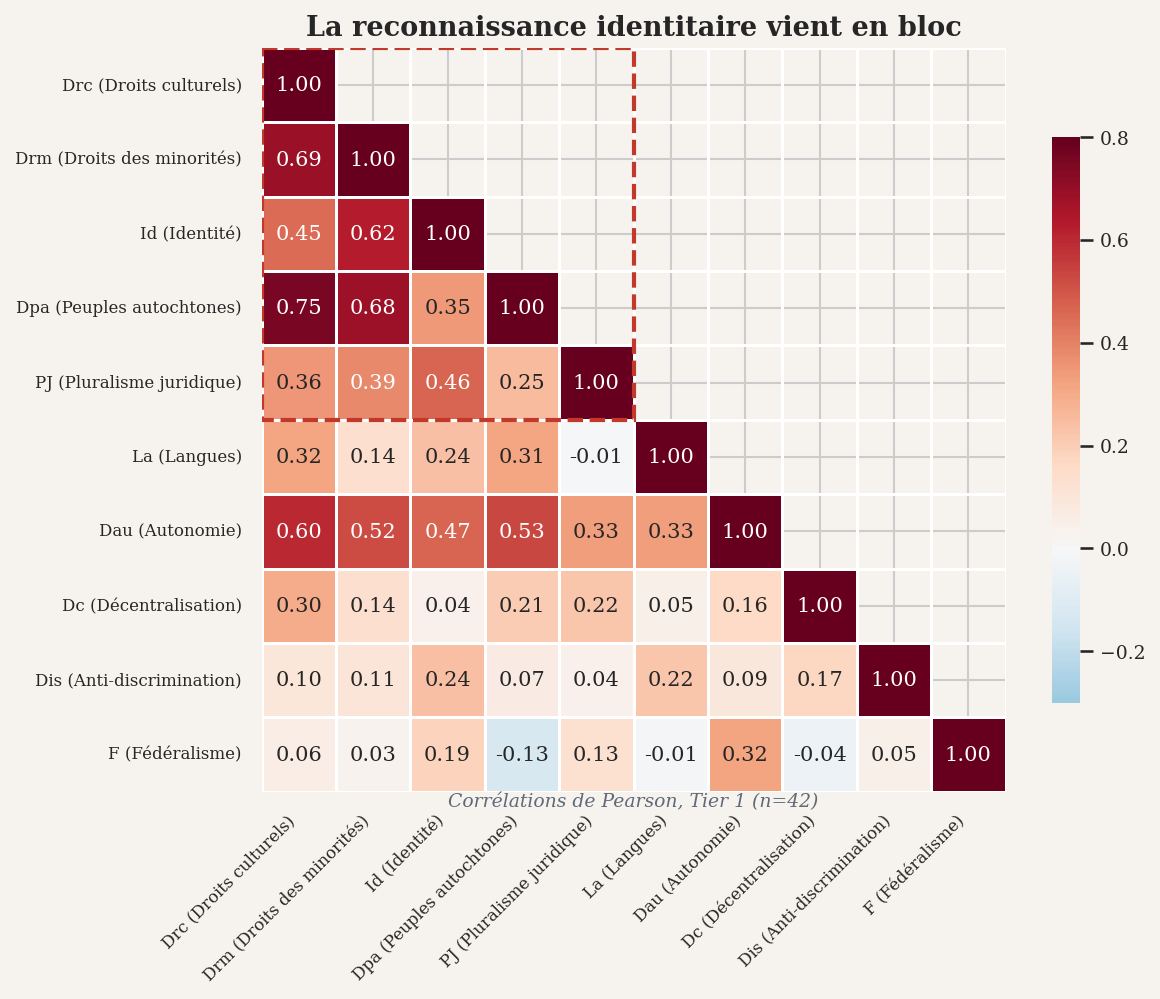

Saved: ch2s2_correlation_matrix (fr + en)


In [4]:
for lang in ('fr', 'en'):
    # Reorder dimensions: identity cluster first
    order = FEATURES_IDENTITY_FIRST
    corr = tier1[order].corr()

    # Labels
    dim_labels = [f'{f} ({t("dim", lang)[f]})' for f in order]

    # Mask upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-0.3, vmax=0.8, square=True, linewidths=0.5,
                xticklabels=dim_labels, yticklabels=dim_labels, ax=ax,
                cbar_kws={'shrink': 0.7})

    ax.set_title(t('correlation_title', lang), fontsize=13, fontweight='bold', fontfamily='serif')
    ax.text(0.5, -0.02, t('correlation_subtitle', lang), transform=ax.transAxes,
            ha='center', fontsize=9, color=C_MUTED, style='italic')

    # Draw box around identity cluster (first 5 dims)
    n_identity = 5
    rect = plt.Rectangle((0, 0), n_identity, n_identity, fill=False,
                          edgecolor=C_PEOPLES, linewidth=2, linestyle='--')
    ax.add_patch(rect)

    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)

    save_fig(fig, 'ch2s2_correlation_matrix', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch2s2_correlation_matrix (fr + en)')

## Figure D: Score Distribution by Heritage

Box + strip plot showing the heritage gap. Cohen's d annotated.

/tmp/ipykernel_92153/716770956.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
/tmp/ipykernel_92153/716770956.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
/tmp/ipykernel_92153/716770956.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=9)


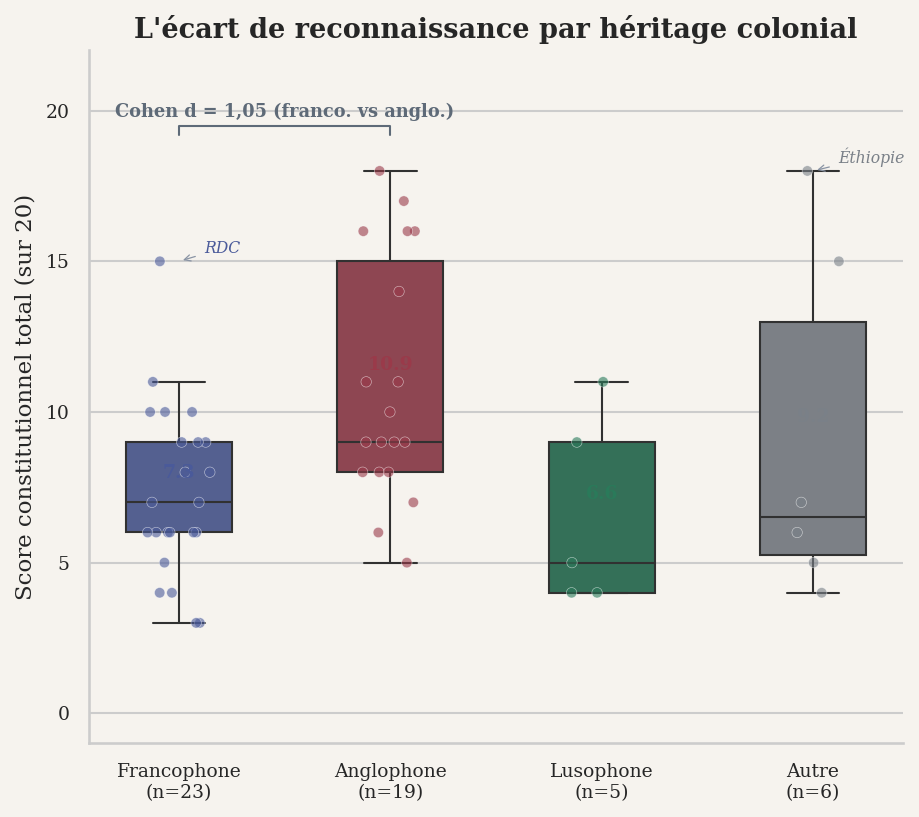

/tmp/ipykernel_92153/716770956.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
/tmp/ipykernel_92153/716770956.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
/tmp/ipykernel_92153/716770956.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=9)


Saved: ch2s2_score_distribution (fr + en)


In [5]:
h_order_4 = ['francophone', 'anglophone', 'lusophone', 'other']
fm_plot = fm[fm['heritage'].isin(h_order_4)].copy()
fm_plot['heritage'] = pd.Categorical(fm_plot['heritage'], categories=h_order_4, ordered=True)

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(7, 6))

    # Box plot
    palette = {h: HC[h] for h in h_order_4}
    sns.boxplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
                width=0.5, fliersize=0, ax=ax, order=h_order_4)

    # Strip plot overlay
    sns.stripplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
                  size=5, alpha=0.6, jitter=0.15, ax=ax, order=h_order_4,
                  edgecolor='white', linewidth=0.3)

    # Heritage labels
    x_labels = [f'{hl(h, lang)}\n(n={len(fm_plot[fm_plot["heritage"]==h])})' for h in h_order_4]
    ax.set_xticklabels(x_labels, fontsize=9)

    # Mean annotations
    for i, h in enumerate(h_order_4):
        mean_val = fm_plot[fm_plot['heritage'] == h]['total_score'].mean()
        ax.text(i, mean_val + 0.5, f'{mean_val:.1f}', ha='center', fontsize=9,
                fontweight='bold', color=HC[h])

    # Cohen's d bracket
    y_bracket = 19.5
    ax.plot([0, 0, 1, 1], [y_bracket - 0.3, y_bracket, y_bracket, y_bracket - 0.3],
            color=C_MUTED, linewidth=1)
    ax.text(0.5, y_bracket + 0.3, t('score_boxplot_annot', lang),
            ha='center', fontsize=8.5, color=C_MUTED, fontweight='bold')

    # Label notable outliers
    for _, row in fm_plot.iterrows():
        if row['PAYS'] in ('République démocratique du Congo', 'Éthiopie'):
            h_idx = h_order_4.index(row['heritage'])
            short = 'RDC' if 'Congo' in row['PAYS'] else row['PAYS']
            ax.annotate(short, (h_idx, row['total_score']),
                        xytext=(12, 4), textcoords='offset points',
                        fontsize=7.5, color=HC[row['heritage']], fontstyle='italic',
                        arrowprops=dict(arrowstyle='->', color=C_DIM, lw=0.6))

    ax.set_xlabel('')
    ax.set_ylabel(t('score_boxplot_ylabel', lang), fontsize=11)
    ax.set_title(t('score_boxplot_title', lang), fontsize=13, fontweight='bold', fontfamily='serif')
    ax.set_ylim(-1, 22)

    save_fig(fig, 'ch2s2_score_distribution', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch2s2_score_distribution (fr + en)')

## Figure E: Fixed Dendrogram (Horizontal)

Horizontal orientation with readable labels. Leaves colored by heritage.

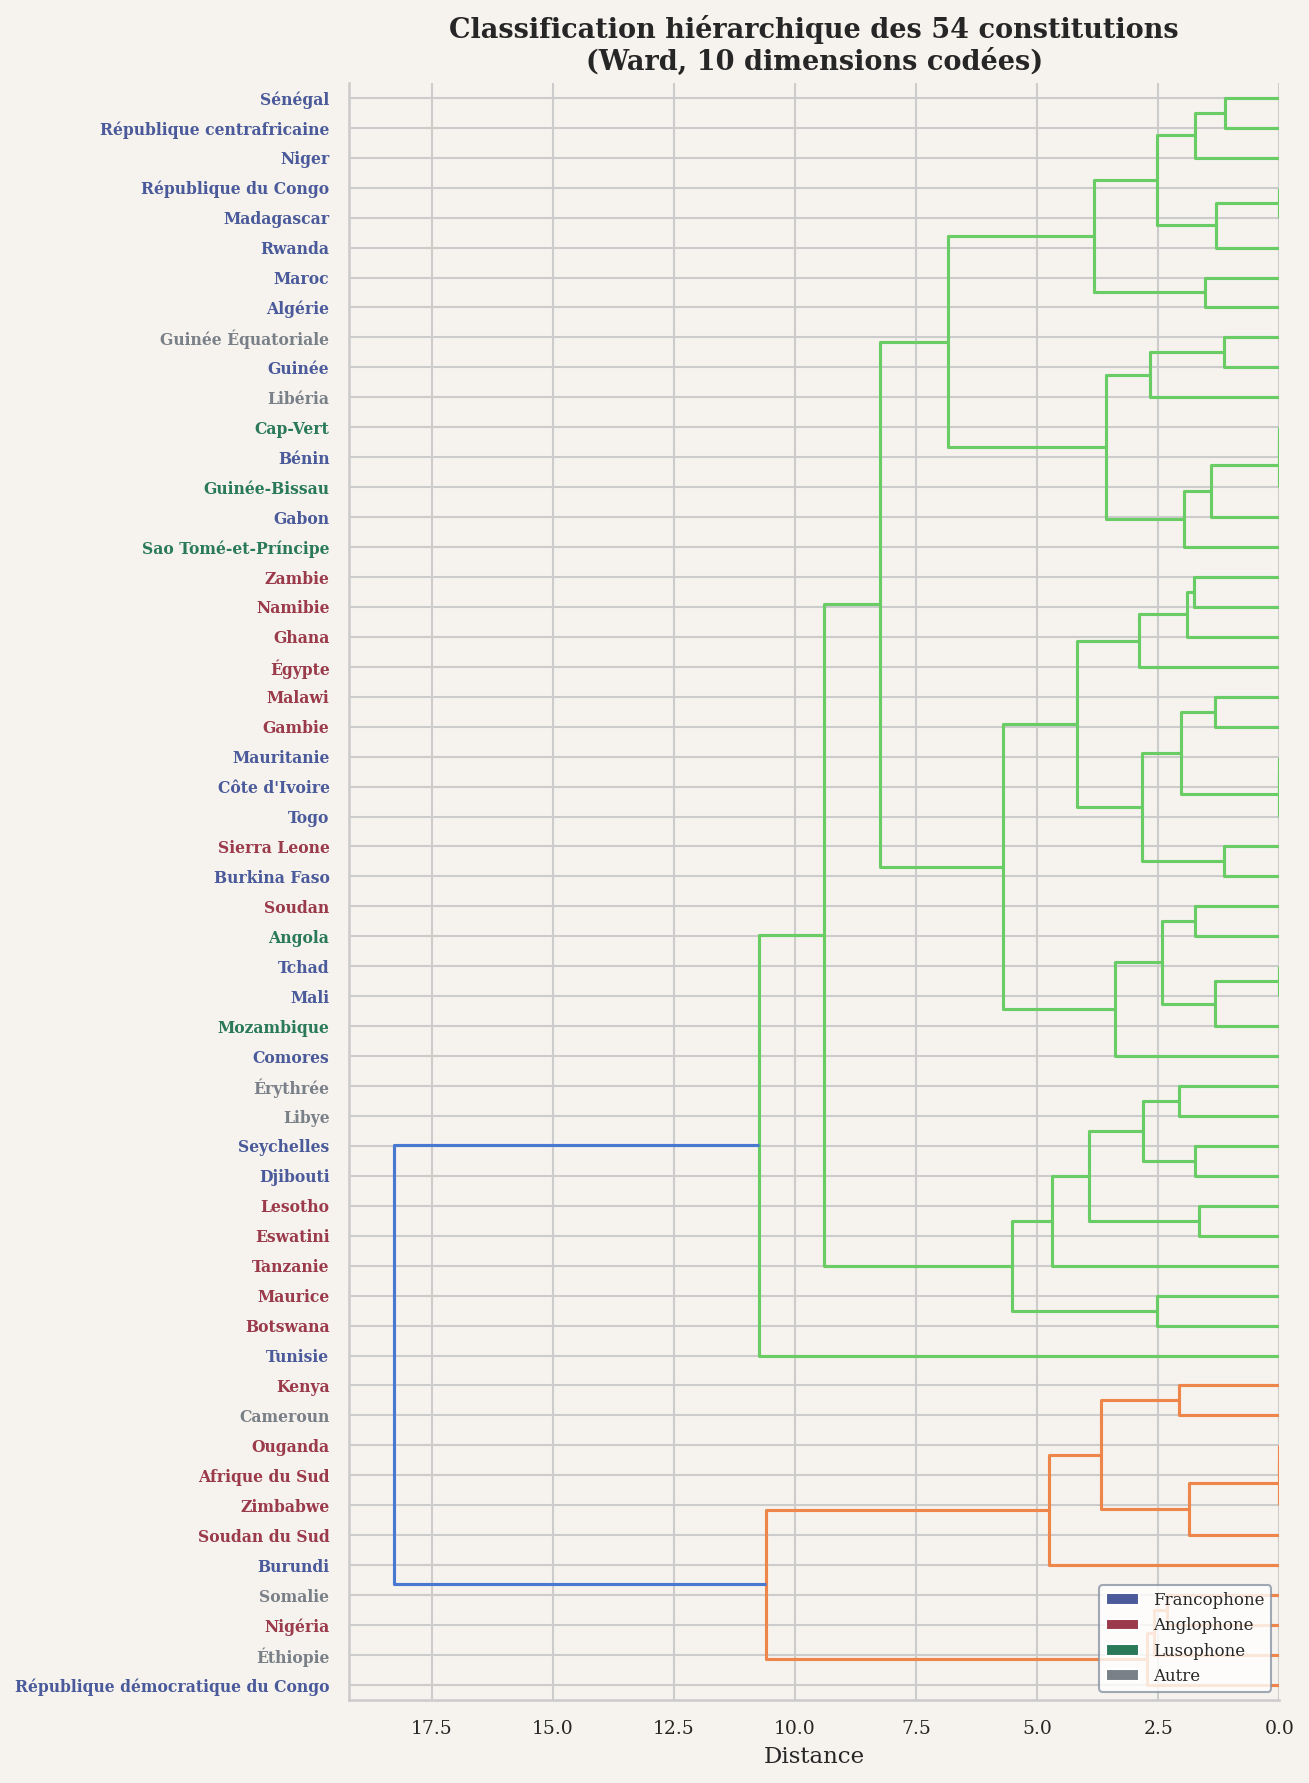

Saved: clusters_dendrogram_dimensions (fr + en)


In [6]:
# Standardize and cluster
X = fm[FEATURES].values
X_scaled = StandardScaler().fit_transform(X)
Z = linkage(X_scaled, method='ward')

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(8, 14))

    dendro = dendrogram(Z, labels=fm['PAYS'].tolist(), orientation='left',
                        leaf_font_size=8, ax=ax, no_labels=True)

    # Color leaves by heritage
    ordered_countries = [fm['PAYS'].tolist()[i] for i in dendro['leaves']]
    y_labels = ax.get_yticks()

    ax.set_yticks(range(5, 5 + 10 * len(ordered_countries), 10))
    ax.set_yticklabels(ordered_countries, fontsize=7.5)

    for tick_label, country in zip(ax.get_yticklabels(), ordered_countries):
        h = DATA['colonial_heritage'].get(country, 'other')
        tick_label.set_color(HC.get(h, C_DIM))
        tick_label.set_fontweight('bold')

    # Legend
    legend_elements = [mpatches.Patch(facecolor=HC[h], label=hl(h, lang))
                       for h in ['francophone', 'anglophone', 'lusophone', 'other']]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True,
              facecolor='white', edgecolor=C_DIM, fontsize=8)

    ax.set_xlabel(t('dendrogram_xlabel', lang), fontsize=11)
    ax.set_title(t('dendrogram_title', lang), fontsize=13, fontweight='bold', fontfamily='serif')

    save_fig(fig, 'clusters_dendrogram_dimensions', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: clusters_dendrogram_dimensions (fr + en)')

## Summary

In [7]:
import glob

print('=== Thesis Figures Generated ===')
for lang in ('fr', 'en'):
    figs = sorted(glob.glob(str(FIG_DIR / lang / '*.pdf')))
    print(f'\n{lang.upper()}: {len(figs)} PDFs')
    for f in figs:
        print(f'  {Path(f).name}')

=== Thesis Figures Generated ===

FR: 5 PDFs
  ch2s1_treaty_beeswarm.pdf
  ch2s2_correlation_matrix.pdf
  ch2s2_heritage_divergence.pdf
  ch2s2_score_distribution.pdf
  clusters_dendrogram_dimensions.pdf

EN: 5 PDFs
  ch2s1_treaty_beeswarm.pdf
  ch2s2_correlation_matrix.pdf
  ch2s2_heritage_divergence.pdf
  ch2s2_score_distribution.pdf
  clusters_dendrogram_dimensions.pdf
